# K-Nearest Neighbors

### ¿Qué es?

* `K-Nearest Neighbors (KNN)` es un algoritmo de aprendizaje supervisado que se puede usar tanto para clasificación como para regresión.
* Un punto se clasifica según la mayoría de sus 'k' vecinos más cercanos en el espacio de características.
* K es el número de vecinos más cercanos que se usarán para hacer la predicción.
* Calcular la distancia entre el nuevo punto y todos los puntos del conjunto de entrenamiento.
* Las distancias más comunes son Euclidiana, Manhattan o Minkowski.
* Hacer la predicción:
  - ***Clasificación***: se asigna la clase mayoritaria entre los vecinos.
  - ***Regresión***: se asigna el promedio de los valores de los vecinos.

![Euclidiana.png](Euclidiana.png)

* Ventajas de KNN
  - Muy simple y fácil de entender.
  - No hace suposiciones sobre la distribución de los datos (no paramétrico).

* Desventajas de KNN
  - Puede ser lento con muchos datos porque calcula distancias con todos los puntos.
  - Sensible a la escala de los datos, por eso se suele normalizar con MinMaxScaler.
  - Elegir un K demasiado pequeño puede generar ruido; K demasiado grande puede suavizar demasiado la predicción.

### Datos de clientes bancarios: crédito

* Estos datos trantan de establecer probabilidades, es decir que dependiendo de los datos que lo rodean pueden establecer la probabilidad de que si sea un deudor o no lo sea.
* Para este caso solo nos dan la edad del acreedor, el monto de su crédito y si pagó o no.

In [2]:
import pandas as pd
import numpy as np

clientes = pd.read_csv("creditos.csv")
clientes

,edad,credito,cumplio
0,18,363112,0
1,19,477965,1
2,20,239072,0
3,22,195265,0
4,22,482174,0
...,...,...,...
195,55,100000,0
196,55,523144,0
197,55,543771,0
198,56,285288,0


### Gráfica: Pagadores VS Deudores

* Simplemente separamos nuestros datos, y los graficamos.
* En esta ocasión simplemente son 2 casos, el algoritmo KNN buscara nuestro punto y revisará quienes están a su al rededor.

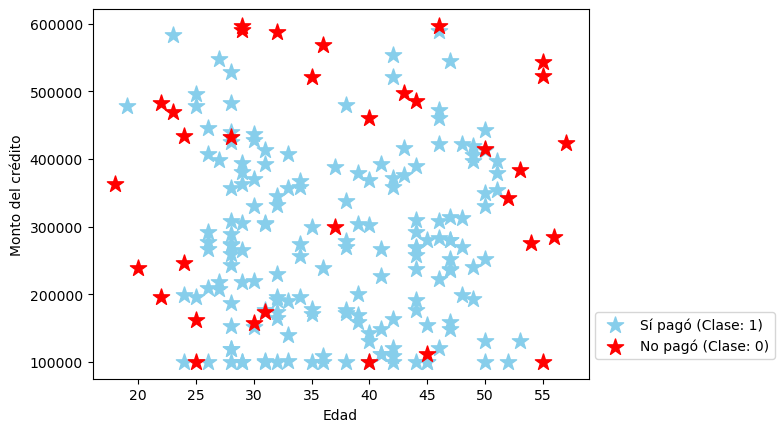

In [3]:
import matplotlib.pyplot as plt

### Separamos nuestros datos dada su clasificación.
buenos = clientes[clientes["cumplio"]==1]
malos = clientes[clientes["cumplio"]==0]

plt.scatter(
    x=buenos["edad"], 
    y=buenos["credito"],
    marker="*", 
    s=150, 
    color="skyblue",
    label="Sí pagó (Clase: 1)")

plt.scatter(
    x=malos["edad"], 
    y=malos["credito"],
    marker="*", s=150, color="red", 
    label="No pagó (Clase: 0)")

plt.ylabel("Monto del crédito")
plt.xlabel("Edad")
plt.legend(bbox_to_anchor=(1, 0.2)) 
plt.show()

### Preparación de los datos (Escalar)

* En este caso, este modelo es muy sensible a las grandes datos contra pequeños, por loque puede meter un sesgo increible.
* Para este caso, tendremos que hacerlo, tanto para edad como crédito. Para la variable objetivo no es necesario ya que solo maneja datos como '1' o '0'.

In [4]:
from sklearn import preprocessing

datos = clientes[["edad", "credito"]]
clase = clientes["cumplio"]

escalador = preprocessing.MinMaxScaler()
datos = escalador.fit_transform(datos)

### Instancia del Modelo KNN

In [5]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    datos,
    clase,
    test_size= 0.20,
    random_state=42
)
clasificador = KNeighborsClassifier(n_neighbors=3)
clasificador.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

### Métricas KNN

* Para KNN, las métricas dependen de si estamos haciendo clasificación o regresión.
* Cuando KNN predice clases, se suelen usar métricas de evaluación de clasificación:
  - `Accuracy (exactitud)`: Porcentaje de predicciones correctas.
  - `Precision (precisión)`: Qué proporción de las predicciones positivas fueron correctas.
  - `Recall (sensibilidad o exhaustividad)`: Qué proporción de los positivos reales fueron correctamente identificados.
  - `F1-Score`: Media armónica de precision y recall.
  - `Matriz de confusión`: Muestra los aciertos y errores por clase. (Falsos Positivos y Verdaderos Negativos)

* Cuando KNN predice valores continuos, se usan métricas de regresión:
  - `Mean Squared Error (MSE)`: Promedio del cuadrado de los errores
  - `Root Mean Squared Error (RMSE)`: Raíz cuadrada del MSE, mantiene unidades originales
  - `Mean Absolute Error (MAE)`: Promedio del valor absoluto de los errores.
  - `R² (Coeficiente de determinación)`: Qué proporción de la varianza se explica con el modelo.

In [19]:
from sklearn.metrics import accuracy_score, confusion_matrix

# 1. Hacer predicciones
y_pred = clasificador.predict(X_test)

# 2. Calcular exactitud (accuracy)
accuracy = accuracy_score(y_test, y_pred)

# 3. Calcular matriz de confusión
matriz = confusion_matrix(y_test, y_pred)

# 4. Imprimir resultados
print(f"Exactitud del modelo: {accuracy:.4f}")
print("Matriz de Confusión:")
print(matriz)

Exactitud del modelo: 0.9250
Matriz de Confusión:
[[ 2  3]
 [ 0 35]]


### Nuevo Solicitante (Clasificación)

* Dados los nuevos datos de un nuevo cliente, vemos como lo clasifica.

Clase: [0]
Probabilidades por clase: [[0.66666667 0.33333333]]


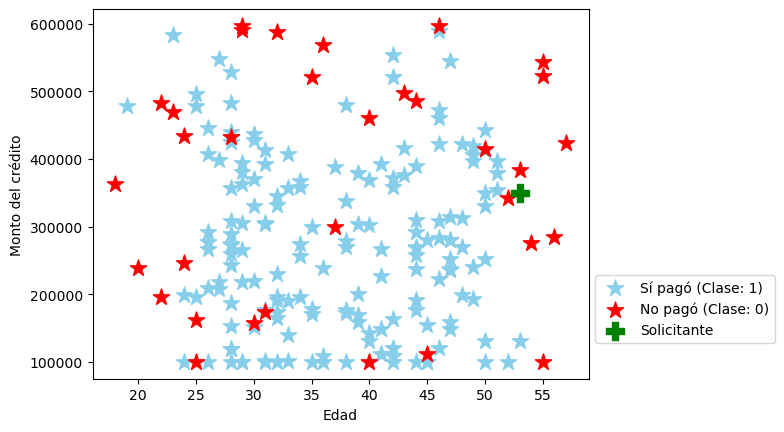

In [8]:
### Movemos estos parametros para ver como lo clasifica.
edad = 53
monto = 350000

solicitante_df = pd.DataFrame([[edad, monto]], columns=["edad", "credito"])
solicitante_escalado = escalador.transform(solicitante_df)

print("Clase:", clasificador.predict(solicitante_escalado))
print("Probabilidades por clase:", clasificador.predict_proba(solicitante_escalado))

#Código para graficar
plt.scatter(buenos["edad"], buenos["credito"],
            marker="*", s=150, color="skyblue", label="Sí pagó (Clase: 1)")
plt.scatter(malos["edad"], malos["credito"],
            marker="*", s=150, color="red", label="No pagó (Clase: 0)")
plt.scatter(edad, monto, marker="P", s=150, color="green", label="Solicitante") 
plt.ylabel("Monto del crédito")
plt.xlabel("Edad")
plt.legend(bbox_to_anchor=(1, 0.3))
plt.show()

### Regiones de las clases

* `np.array([np.arange(100000, 600010, 1000)]*43).reshape(1, -1)`: le estamos diciendo que genere un array que empieza en 100,000, termina en 600,010, con pasos de 1000. Crea una lista de 43 referencias al mismo array de 501 elementos. Esto se convierte luego en un array de forma (43, 501). El array de forma (43, 501) se aplana a una sola fila de longitud 43 × 501 = 21543 elementos.
* Por eso para edades generamos esas refencuas por 501.
* Creamos un dataframe con todos estos datos y escalamos los datos.
* Hacemos un predict de todos estos datos, podemos ver como creamos zonas donde se hallarían los no pagadores y los que si.

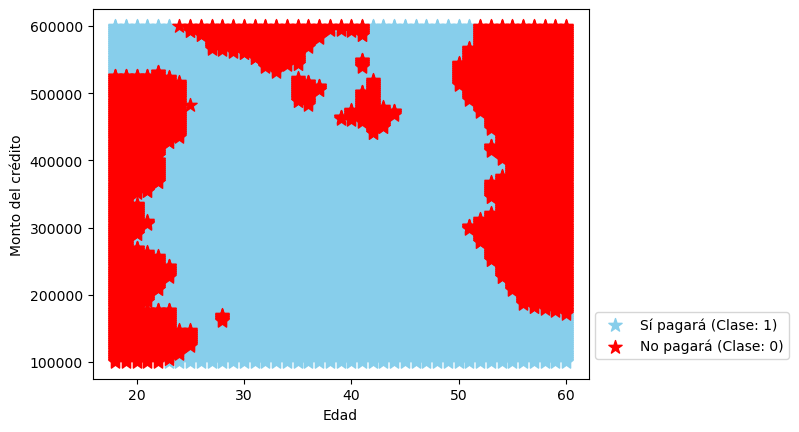

In [10]:
#Datos sinténticos de todos los posibles solicitantes
creditos = np.array([np.arange(100000, 600010, 1000)]*43).reshape(1, -1)
edades = np.array([np.arange(18, 61)]*501).reshape(1, -1)
todos = pd.DataFrame(np.stack((edades, creditos), axis=2)[0],
                     columns=["edad", "credito"])

#Escalar los datos
solicitantes = escalador.transform(todos)

#Predecir todas las clases
clases_resultantes = clasificador.predict(solicitantes)

#Código para graficar
buenos = todos[clases_resultantes==1]
malos = todos[clases_resultantes==0]
plt.scatter(buenos["edad"], buenos["credito"],
            marker="*", s=100, color="skyblue", label="Sí pagará (Clase: 1)")
plt.scatter(malos["edad"], malos["credito"],
            marker="*", s=100, color="red", label="No pagará (Clase: 0)")
plt.ylabel("Monto del crédito")
plt.xlabel("Edad")
plt.legend(bbox_to_anchor=(1, 0.2))
plt.show()